# Prequential Evaluation of Surrogate Models — Function 2

**Objective**: Compare three surrogate model families on the noisy log-likelihood maximisation problem (Function 2) using **prequential (one-step-ahead) evaluation**.

## Function 2 Properties

| Property | Value |
|----------|-------|
| Problem | Noisy log-likelihood estimation (mystery ML model) |
| Input dimensions | 2 |
| Output dimensions | 1 |
| Objective | Maximise |
| Output range | Moderate: [-0.07, 0.67] |
| Initial samples | 10 |
| Total samples (Week 6) | 16 |
| Evaluation steps | 6 one-step-ahead predictions |

## Surrogate Models

1. **Gaussian Process (GP)** — via BoTorch/GPyTorch
2. **BART (Bayesian Additive Regression Trees)** — via PyMC-BART
3. **Random Forest (RF)** — via scikit-learn

## Methodology

For each surrogate, we:
1. Train on the initial 10 data points
2. Predict the next observation (one-step-ahead)
3. Record (prediction, uncertainty, actual)
4. Add the new point to the training set and retrain
5. Repeat until all 16 points have been processed (6 evaluation steps)

Each family is evaluated with **10 hyperparameter configurations** (30 total), and the best configuration from each family is compared in a 3-way comparison.

## Evaluation Metrics

We evaluate each surrogate using three metrics:

1. **MAE (Mean Absolute Error)**: Average absolute difference between predicted and actual values. Lower is better.

2. **NLP (Negative Log Predictive Density)**: Measures calibration quality — penalises both inaccurate means and overconfident/underconfident uncertainty. Lower is better.

   $$\text{NLP}_i = \frac{1}{2} \log(2\pi\sigma_i^2) + \frac{(y_i - \mu_i)^2}{2\sigma_i^2}$$

3. **95% Coverage**: Proportion of actual values falling within the 95% prediction interval ($\mu \pm 1.96\sigma$). Ideal value is 0.95.

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# BoTorch / GPyTorch for Gaussian Process
import gpytorch
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import MaternKernel, RBFKernel, ScaleKernel
from gpytorch.constraints import GreaterThan
from gpytorch.likelihoods import GaussianLikelihood

# PyMC / BART
import pymc as pm
import pymc_bart as pmb

# scikit-learn for Random Forest
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)
torch.manual_seed(42)
print('All imports successful.')

All imports successful.


## Step 1: Load Data

Load the Function 2 data. The `WEEK` variable controls which data snapshot to use (default: Week 6 with 16 total data points — 10 initial + 6 sequential observations).

In [2]:
# ── Configuration ─────────────────────────────────────────────
WEEK = 6
N_INIT = 10  # Number of initial training points

# ── Load data ─────────────────────────────────────────────────
X_all = np.load(f'../../data/f2/updated_inputs - Week {WEEK}.npy')
y_all = np.load(f'../../data/f2/updated_outputs - Week {WEEK}.npy')

# Flatten y if needed
if y_all.ndim > 1:
    y_all = y_all.flatten()

n_total = len(y_all)
n_steps = n_total - N_INIT

print(f'Function 2 — Noisy Log-Likelihood Maximisation')
print(f'  Data loaded: Week {WEEK}')
print(f'  X shape: {X_all.shape}  (input dimensions: {X_all.shape[1]})')
print(f'  y shape: {y_all.shape}')
print(f'  Output range: [{y_all.min():.6f}, {y_all.max():.6f}]')
print(f'  Output mean:  {y_all.mean():.6f}')
print(f'  Output std:   {y_all.std():.6f}')
print(f'  Initial training points: {N_INIT}')
print(f'  Evaluation steps: {n_steps}')

Function 2 — Noisy Log-Likelihood Maximisation
  Data loaded: Week 6
  X shape: (16, 2)  (input dimensions: 2)
  y shape: (16,)
  Output range: [-0.065624, 0.674355]
  Output mean:  0.306161
  Output std:   0.248348
  Initial training points: 10
  Evaluation steps: 6


## Step 2: Define Evaluation Metrics

The `compute_metrics()` function computes MAE, NLP, and 95% Coverage from the one-step-ahead predictions.

In [3]:
def compute_metrics(predictions, actuals, pred_means, pred_stds):
    """
    Compute prequential evaluation metrics.
    
    Parameters
    ----------
    predictions : list of float — point predictions (mean) for each step
    actuals     : list of float — actual observed values for each step
    pred_means  : list of float — predicted means (same as predictions)
    pred_stds   : list of float — predicted standard deviations (uncertainty)
    
    Returns
    -------
    dict with MAE, NLP, Coverage_95, and per-step details
    """
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    pred_means = np.array(pred_means)
    pred_stds = np.array(pred_stds)
    
    # MAE
    mae = np.mean(np.abs(actuals - predictions))
    
    # Negative Log Predictive Density (NLP)
    # NLP_i = 0.5 * log(2*pi*sigma^2) + (y - mu)^2 / (2*sigma^2)
    stds_clipped = np.clip(pred_stds, 1e-10, None)
    nlp_values = 0.5 * np.log(2 * np.pi * stds_clipped**2) + \
                 (actuals - pred_means)**2 / (2 * stds_clipped**2)
    mean_nlp = np.mean(nlp_values)
    
    # 95% Prediction Interval Coverage
    lower = pred_means - 1.96 * stds_clipped
    upper = pred_means + 1.96 * stds_clipped
    in_interval = (actuals >= lower) & (actuals <= upper)
    coverage_95 = np.mean(in_interval)
    
    return {
        'MAE': mae,
        'NLP': mean_nlp,
        'Coverage_95': coverage_95,
        'nlp_values': nlp_values,
        'errors': actuals - predictions,
        'in_interval': in_interval
    }

print('compute_metrics() defined.')

compute_metrics() defined.


## Step 3: GP Prequential Evaluation

Default GP uses Matérn 5/2 kernel with ARD (Automatic Relevance Determination), learned noise level, and Maximum Likelihood Estimation (MLE) fitting via `fit_gpytorch_mll`.

In [4]:
def gp_prequential_evaluation(X_all, y_all, n_init):
    """
    Perform one-step-ahead prequential evaluation using a Gaussian Process.
    Default: Matern 5/2 kernel, ARD, learned noise.
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running GP (Matern 5/2) prequential evaluation...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_all[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_all[n_train]
        
        # Build and fit GP model
        model = SingleTaskGP(X_train, y_train)
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        fit_gpytorch_mll(mll)
        
        # Predict
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('gp_prequential_evaluation() defined.')

gp_prequential_evaluation() defined.


### Run GP with Default Hyperparameters

In [5]:
gp_default_results = gp_prequential_evaluation(X_all, y_all, N_INIT)

Running GP (Matern 5/2) prequential evaluation...
  Training starts with 10 points, evaluating 6 steps

  Step 1: train=10 pts | predicted=+0.616934 | actual=+0.674355 | error=+0.057421 | std=0.025267
  Step 2: train=11 pts | predicted=+0.305197 | actual=+0.054376 | error=-0.250821 | std=0.239526
  Step 3: train=12 pts | predicted=+0.617593 | actual=+0.546395 | error=-0.071198 | std=0.079269
  Step 4: train=13 pts | predicted=+0.622875 | actual=+0.552994 | error=-0.069882 | std=0.089639
  Step 5: train=14 pts | predicted=+0.667318 | actual=+0.597369 | error=-0.069949 | std=0.021554
  Step 6: train=15 pts | predicted=+0.275043 | actual=+0.166356 | error=-0.108687 | std=0.079114

  Results:
    MAE:          0.104660
    Mean NLP:     -0.1445
    95% Coverage: 66.7%


### GP Default Results — Visualisation

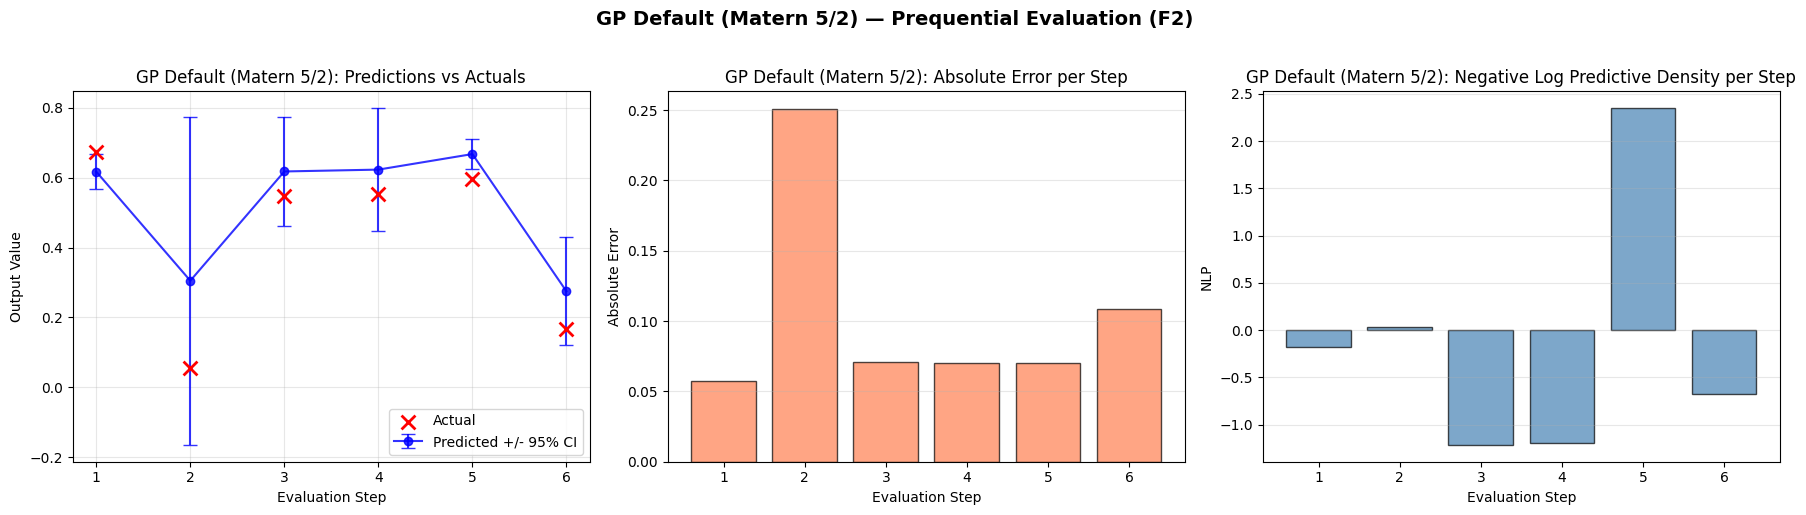

In [6]:
def plot_prequential_results(results, model_name):
    """Plot prequential evaluation results for a single model."""
    actuals = np.array(results['actuals'])
    preds = np.array(results['pred_means'])
    stds = np.array(results['pred_stds'])
    steps = np.arange(1, len(actuals) + 1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Predictions vs Actuals with uncertainty
    ax = axes[0]
    ax.errorbar(steps, preds, yerr=1.96*stds, fmt='o-', color='blue',
                capsize=5, label='Predicted +/- 95% CI', alpha=0.8)
    ax.scatter(steps, actuals, color='red', s=100, zorder=5,
               marker='x', linewidths=2, label='Actual')
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Output Value')
    ax.set_title(f'{model_name}: Predictions vs Actuals')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot 2: Absolute errors
    ax = axes[1]
    errors = np.abs(actuals - preds)
    ax.bar(steps, errors, color='coral', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('Absolute Error')
    ax.set_title(f'{model_name}: Absolute Error per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: NLP per step
    ax = axes[2]
    nlp_vals = results['metrics']['nlp_values']
    ax.bar(steps, nlp_vals, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Evaluation Step')
    ax.set_ylabel('NLP')
    ax.set_title(f'{model_name}: Negative Log Predictive Density per Step')
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(f'{model_name} — Prequential Evaluation (F2)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

plot_prequential_results(gp_default_results, 'GP Default (Matern 5/2)')

### GP Hyperparameter Optimisation (10 Configurations)

We evaluate 10 GP configurations varying:
- **Kernel type**: Matérn 5/2 vs RBF
- **Output log-transform**: raw vs log(|y| + eps) — included for robustness even though F2's moderate output range likely doesn't need it
- **Noise lower bound**: 1e-4, 1e-5, 1e-6

In [7]:
def gp_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run GP prequential evaluation with a specific configuration.
    
    config dict keys:
        kernel_type   : 'matern' or 'rbf'
        log_transform : bool - apply log(|y|+eps) transform
        noise_lb      : float - lower bound for noise
    """
    EPS = 1e-300
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    # Optionally transform outputs: z = log(|y| + eps)
    if config.get('log_transform', False):
        y_work = np.log(np.abs(y_all) + EPS)
    else:
        y_work = y_all.copy()
    
    predictions = []
    actuals_transformed = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = torch.tensor(X_all[:n_train], dtype=torch.float64)
        y_train = torch.tensor(y_work[:n_train], dtype=torch.float64).unsqueeze(-1)
        
        X_test = torch.tensor(X_all[n_train:n_train+1], dtype=torch.float64)
        y_actual = y_work[n_train]
        
        # Build kernel based on config
        d = X_train.shape[-1]
        if config.get('kernel_type', 'matern') == 'rbf':
            base_kernel = RBFKernel(ard_num_dims=d)
        else:
            base_kernel = MaternKernel(nu=2.5, ard_num_dims=d)
        covar_module = ScaleKernel(base_kernel)
        
        # Build likelihood with noise lower bound
        noise_lb = config.get('noise_lb', 1e-5)
        likelihood = GaussianLikelihood(noise_constraint=GreaterThan(noise_lb))
        
        # Build GP model
        model = SingleTaskGP(
            X_train, y_train,
            covar_module=covar_module,
            likelihood=likelihood,
        )
        mll = ExactMarginalLogLikelihood(model.likelihood, model)
        
        try:
            fit_gpytorch_mll(mll)
        except Exception:
            pass  # Use current hyperparameters if fitting fails
        
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(X_test)
            mean = posterior.mean.item()
            std = posterior.variance.sqrt().item()
        
        predictions.append(mean)
        actuals_transformed.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    # Metrics in the space the model operates in
    metrics = compute_metrics(predictions, actuals_transformed, pred_means, pred_stds)
    
    # Also compute MAE in original space for interpretability
    if config.get('log_transform', False):
        orig_preds = np.exp(np.array(predictions)) - EPS
        orig_preds = np.maximum(orig_preds, 0.0)
        orig_actuals = y_all[n_init:]
        metrics['MAE_original'] = np.mean(np.abs(orig_actuals - orig_preds))
    else:
        metrics['MAE_original'] = metrics['MAE']
    
    return metrics


# ── 10 GP Hyperparameter Configurations ───────────────────────
hp_configs = [
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'Matern, raw, noise>=1e-5'},
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'Matern, raw, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': False, 'noise_lb': 1e-6,
     'label': 'Matern, raw, noise>=1e-6'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-5,
     'label': 'RBF, raw, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': False, 'noise_lb': 1e-4,
     'label': 'RBF, raw, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'Matern, log-transform, noise>=1e-5'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'Matern, log-transform, noise>=1e-4'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-5,
     'label': 'RBF, log-transform, noise>=1e-5'},
    {'kernel_type': 'rbf', 'log_transform': True, 'noise_lb': 1e-4,
     'label': 'RBF, log-transform, noise>=1e-4'},
    {'kernel_type': 'matern', 'log_transform': True, 'noise_lb': 1e-6,
     'label': 'Matern, log-transform, noise>=1e-6'},
]

print(f'Running {len(hp_configs)} GP configurations...\n')

gp_hp_results = []
for i, config in enumerate(hp_configs):
    print(f'  Config {i+1}/{len(hp_configs)}: {config["label"]}')
    try:
        metrics = gp_prequential_with_config(X_all, y_all, N_INIT, config)
        gp_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95'],
            'MAE_original': metrics['MAE_original']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        gp_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan,
            'MAE_original': np.nan
        })

gp_hp_df = pd.DataFrame(gp_hp_results)
print(f'\nGP Hyperparameter Results:')
gp_hp_df

Running 10 GP configurations...

  Config 1/10: Matern, raw, noise>=1e-5
    MAE=0.095469  NLP=-0.3512  Coverage=66.7%
  Config 2/10: Matern, raw, noise>=1e-4
    MAE=0.095488  NLP=-0.3513  Coverage=66.7%
  Config 3/10: Matern, raw, noise>=1e-6
    MAE=0.095469  NLP=-0.3513  Coverage=66.7%
  Config 4/10: RBF, raw, noise>=1e-5
    MAE=0.094536  NLP=-0.0647  Coverage=66.7%
  Config 5/10: RBF, raw, noise>=1e-4
    MAE=0.094554  NLP=-0.0644  Coverage=66.7%
  Config 6/10: Matern, log-transform, noise>=1e-5
    MAE=0.316328  NLP=0.1776  Coverage=100.0%
  Config 7/10: Matern, log-transform, noise>=1e-4
    MAE=0.316321  NLP=0.1776  Coverage=100.0%
  Config 8/10: RBF, log-transform, noise>=1e-5
    MAE=0.565070  NLP=1.1115  Coverage=66.7%
  Config 9/10: RBF, log-transform, noise>=1e-4
    MAE=0.565084  NLP=1.1116  Coverage=66.7%
  Config 10/10: Matern, log-transform, noise>=1e-6
    MAE=0.316327  NLP=0.1776  Coverage=100.0%

GP Hyperparameter Results:


,label,MAE,NLP,Coverage_95,MAE_original
0,"Matern, raw, noise>=1e-5",0.095469,-0.351242,0.666667,0.095469
1,"Matern, raw, noise>=1e-4",0.095488,-0.351315,0.666667,0.095488
2,"Matern, raw, noise>=1e-6",0.095469,-0.351320,0.666667,0.095469
3,"RBF, raw, noise>=1e-5",0.094536,-0.064693,0.666667,0.094536
4,"RBF, raw, noise>=1e-4",0.094554,-0.064433,0.666667,0.094554
5,"Matern, log-transform, noise>=1e-5",0.316328,0.177585,1.000000,0.063762
6,"Matern, log-transform, noise>=1e-4",0.316321,0.177584,1.000000,0.063762
7,"RBF, log-transform, noise>=1e-5",0.565070,1.111513,0.666667,0.138662
8,"RBF, log-transform, noise>=1e-4",0.565084,1.111566,0.666667,0.138665
9,"Matern, log-transform, noise>=1e-6",0.316327,0.177582,1.000000,0.063762


### Best GP Configuration

In [8]:
# Best GP by NLP (primary metric)
best_gp_idx = gp_hp_df['NLP'].idxmin()
best_gp = gp_hp_df.loc[best_gp_idx]
print(f'Best GP by NLP:')
print(f'  Config:    {best_gp["label"]}')
print(f'  MAE:       {best_gp["MAE"]:.6f}')
print(f'  NLP:       {best_gp["NLP"]:.4f}')
print(f'  Coverage:  {best_gp["Coverage_95"]:.1%}')

# Best GP by MAE (secondary)
best_mae_idx = gp_hp_df['MAE'].idxmin()
if best_mae_idx != best_gp_idx:
    best_mae = gp_hp_df.loc[best_mae_idx]
    print(f'\nBest GP by MAE (different from NLP-best):')
    print(f'  Config:    {best_mae["label"]}')
    print(f'  MAE:       {best_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_mae["NLP"]:.4f}')

Best GP by NLP:
  Config:    Matern, raw, noise>=1e-6
  MAE:       0.095469
  NLP:       -0.3513
  Coverage:  66.7%

Best GP by MAE (different from NLP-best):
  Config:    RBF, raw, noise>=1e-5
  MAE:       0.094536
  NLP:       -0.0647


## Step 4: BART Prequential Evaluation

BART (Bayesian Additive Regression Trees) is a non-parametric Bayesian model that sums many small regression trees. We use PyMC-BART for sampling.

Default: m=50 trees, 500 MCMC draws, 200 burn-in samples.

In [9]:
def bart_prequential_evaluation(X_all, y_all, n_init, m_trees=50, draws=500, tune=200):
    """
    Perform one-step-ahead prequential evaluation using BART (PyMC-BART).
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running BART prequential evaluation (m={m_trees}, draws={draws}, tune={tune})...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # Build BART model with PyMC
        with pm.Model() as bart_model:
            X_shared = pm.Data('X', X_train)
            y_shared = pm.Data('y_obs', y_train)
            
            mu = pmb.BART('mu', X=X_shared, Y=y_train, m=m_trees)
            sigma = pm.HalfNormal('sigma', sigma=np.std(y_train) + 1e-10)
            likelihood = pm.Normal('y', mu=mu, sigma=sigma, observed=y_shared)
            
            trace = pm.sample(
                draws=draws, tune=tune, cores=1,
                random_seed=42, progressbar=False,
                return_inferencedata=True
            )
        
        # Predict at test point
        with bart_model:
            pm.set_data({'X': X_test})
            ppc = pm.sample_posterior_predictive(
                trace, random_seed=42, progressbar=False
            )
        
        y_pred_samples = ppc.posterior_predictive['y'].values.flatten()
        mean = np.mean(y_pred_samples)
        std = np.std(y_pred_samples)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('bart_prequential_evaluation() defined.')

bart_prequential_evaluation() defined.


### Run BART with Default Hyperparameters

In [10]:
bart_default_results = bart_prequential_evaluation(X_all, y_all, N_INIT, m_trees=50, draws=500, tune=200)

Running BART prequential evaluation (m=50, draws=500, tune=200)...
  Training starts with 10 points, evaluating 6 steps



Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=+0.351313 | actual=+0.674355 | error=+0.323043 | std=0.071052


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=+0.259050 | actual=+0.054376 | error=-0.204674 | std=0.073476


...

  Step 4: train=13 pts | predicted=+0.455876 | actual=+0.552994 | error=+0.097117 | std=0.083620


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 5: train=14 pts | predicted=+0.601679 | actual=+0.597369 | error=-0.004310 | std=0.055335


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 9 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 6: train=15 pts | predicted=+0.470615 | actual=+0.166356 | error=-0.304259 | std=0.057503

  Results:
    MAE:          0.171134
    Mean NLP:     3.1913
    95% Coverage: 50.0%


### BART Default Results — Visualisation

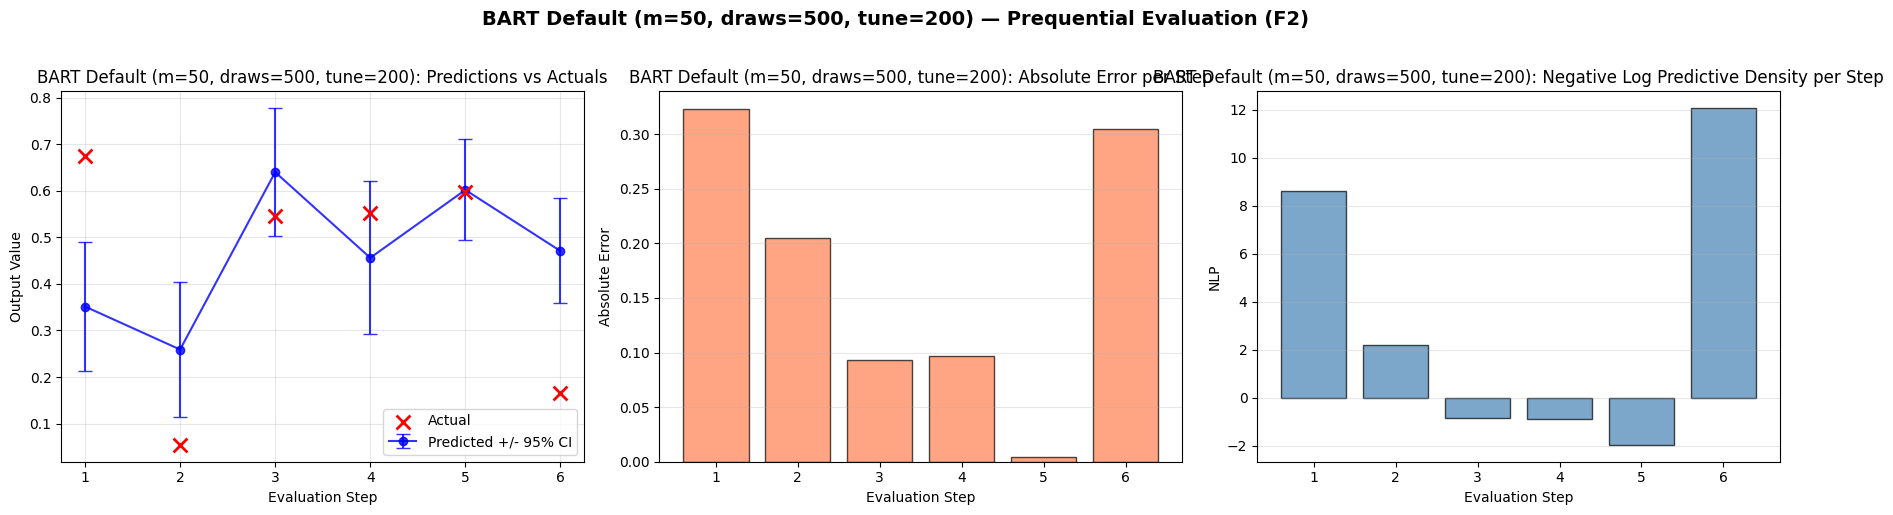

In [11]:
plot_prequential_results(bart_default_results, 'BART Default (m=50, draws=500, tune=200)')

### BART Hyperparameter Optimisation (10 Configurations)

We evaluate 10 BART configurations varying:
- **Number of trees (m)**: 10, 20, 50, 100, 200
- **MCMC draws**: 200, 500
- **Burn-in/tune**: 100, 200

In [12]:
bart_configs = [
    {'m_trees': 10,  'draws': 500, 'tune': 200, 'label': 'm=10, draws=500, tune=200'},
    {'m_trees': 20,  'draws': 500, 'tune': 200, 'label': 'm=20, draws=500, tune=200'},
    {'m_trees': 50,  'draws': 500, 'tune': 200, 'label': 'm=50, draws=500, tune=200'},
    {'m_trees': 100, 'draws': 500, 'tune': 200, 'label': 'm=100, draws=500, tune=200'},
    {'m_trees': 200, 'draws': 500, 'tune': 200, 'label': 'm=200, draws=500, tune=200'},
    {'m_trees': 10,  'draws': 200, 'tune': 100, 'label': 'm=10, draws=200, tune=100'},
    {'m_trees': 20,  'draws': 200, 'tune': 100, 'label': 'm=20, draws=200, tune=100'},
    {'m_trees': 50,  'draws': 200, 'tune': 100, 'label': 'm=50, draws=200, tune=100'},
    {'m_trees': 100, 'draws': 200, 'tune': 100, 'label': 'm=100, draws=200, tune=100'},
    {'m_trees': 200, 'draws': 200, 'tune': 100, 'label': 'm=200, draws=200, tune=100'},
]

print(f'Running {len(bart_configs)} BART configurations...\n')

bart_hp_results = []
for i, config in enumerate(bart_configs):
    print(f'  Config {i+1}/{len(bart_configs)}: {config["label"]}')
    try:
        result = bart_prequential_evaluation(
            X_all, y_all, N_INIT,
            m_trees=config['m_trees'],
            draws=config['draws'],
            tune=config['tune']
        )
        bart_hp_results.append({
            'label': config['label'],
            'MAE': result['metrics']['MAE'],
            'NLP': result['metrics']['NLP'],
            'Coverage_95': result['metrics']['Coverage_95']
        })
        print(f'    MAE={result["metrics"]["MAE"]:.6f}  NLP={result["metrics"]["NLP"]:.4f}  Coverage={result["metrics"]["Coverage_95"]:.1%}\n')
    except Exception as e:
        print(f'    FAILED: {e}\n')
        bart_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan
        })

bart_hp_df = pd.DataFrame(bart_hp_results)
print(f'\nBART Hyperparameter Results:')
bart_hp_df

Running 10 BART configurations...

  Config 1/10: m=10, draws=500, tune=200
Running BART prequential evaluation (m=10, draws=500, tune=200)...
  Training starts with 10 points, evaluating 6 steps



Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 1: train=10 pts | predicted=+0.454353 | actual=+0.674355 | error=+0.220002 | std=0.087375


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 200 tune and 500 draw iterations (400 + 1_000 draws total) took 3 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 2: train=11 pts | predicted=+0.267476 | actual=+0.054376 | error=-0.213101 | std=0.098970


...

Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 200 draw iterations (200 + 400 draws total) took 16 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 5: train=14 pts | predicted=+0.638623 | actual=+0.597369 | error=-0.041254 | std=0.030232


Sequential sampling (2 chains in 1 job)
CompoundStep
>PGBART: [mu]
>NUTS: [sigma]
Sampling 2 chains for 100 tune and 200 draw iterations (200 + 400 draws total) took 18 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Sampling: [mu, y]


  Step 6: train=15 pts | predicted=+0.487423 | actual=+0.166356 | error=-0.321067 | std=0.097250

  Results:
    MAE:          0.152035
    Mean NLP:     4.4090
    95% Coverage: 33.3%
    MAE=0.152035  NLP=4.4090  Coverage=33.3%


BART Hyperparameter Results:


,label,MAE,NLP,Coverage_95
0,"m=10, draws=500, tune=200",0.166814,1.714522,0.500000
1,"m=20, draws=500, tune=200",0.154429,1.683711,0.666667
2,"m=50, draws=500, tune=200",0.185805,4.871046,0.500000
3,"m=100, draws=500, tune=200",0.150933,5.827134,0.333333
4,"m=200, draws=500, tune=200",0.151589,4.883656,0.500000
5,"m=10, draws=200, tune=100",0.160443,0.276284,0.666667
6,"m=20, draws=200, tune=100",0.167233,0.842462,0.500000
7,"m=50, draws=200, tune=100",0.157687,1.164908,0.500000
8,"m=100, draws=200, tune=100",0.156207,0.790162,0.666667
9,"m=200, draws=200, tune=100",0.152035,4.408959,0.333333


### Best BART Configuration

In [13]:
# Best BART by NLP (primary metric)
best_bart_idx = bart_hp_df['NLP'].idxmin()
best_bart = bart_hp_df.loc[best_bart_idx]
print(f'Best BART by NLP:')
print(f'  Config:    {best_bart["label"]}')
print(f'  MAE:       {best_bart["MAE"]:.6f}')
print(f'  NLP:       {best_bart["NLP"]:.4f}')
print(f'  Coverage:  {best_bart["Coverage_95"]:.1%}')

# Best BART by MAE (secondary)
best_bart_mae_idx = bart_hp_df['MAE'].idxmin()
if best_bart_mae_idx != best_bart_idx:
    best_bart_mae = bart_hp_df.loc[best_bart_mae_idx]
    print(f'\nBest BART by MAE (different from NLP-best):')
    print(f'  Config:    {best_bart_mae["label"]}')
    print(f'  MAE:       {best_bart_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_bart_mae["NLP"]:.4f}')

Best BART by NLP:
  Config:    m=10, draws=200, tune=100
  MAE:       0.160443
  NLP:       0.2763
  Coverage:  66.7%

Best BART by MAE (different from NLP-best):
  Config:    m=100, draws=500, tune=200
  MAE:       0.150933
  NLP:       5.8271


## Step 5: Random Forest Prequential Evaluation

Random Forest is an ensemble of decision trees. Unlike GP and BART, RF does not have a built-in probabilistic uncertainty estimate. We derive uncertainty from the **variance across individual tree predictions**:

- **Predicted mean**: Average of all tree predictions
- **Predicted std**: Standard deviation of all tree predictions

This gives us the uncertainty needed for NLP and 95% coverage computation.

Default: n_estimators=100, max_depth=None, min_samples_leaf=1, bootstrap=True.

In [ ]:
def rf_prequential_evaluation(X_all, y_all, n_init, n_estimators=100,
                               max_depth=None, min_samples_leaf=1,
                               bootstrap=True):
    """
    Perform one-step-ahead prequential evaluation using Random Forest.
    
    Uncertainty is estimated via the variance across individual tree predictions.
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    print(f'Running RF prequential evaluation (n_estimators={n_estimators}, '
          f'max_depth={max_depth}, min_samples_leaf={min_samples_leaf}, '
          f'bootstrap={bootstrap})...')
    print(f'  Training starts with {n_init} points, evaluating {n_steps} steps\n')
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        # Build and fit Random Forest
        rf = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            bootstrap=bootstrap,
            random_state=42
        )
        rf.fit(X_train, y_train)
        
        # Predict using individual trees for uncertainty
        tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])
        mean = tree_preds.mean()
        std = tree_preds.std()
        
        # Ensure minimum std for numerical stability
        std = max(std, 1e-10)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
        
        print(f'  Step {step+1}: train={n_train} pts | '
              f'predicted={mean:+.6f} | actual={y_actual:+.6f} | '
              f'error={y_actual - mean:+.6f} | std={std:.6f}')
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    
    print(f'\n  Results:')
    print(f'    MAE:          {metrics["MAE"]:.6f}')
    print(f'    Mean NLP:     {metrics["NLP"]:.4f}')
    print(f'    95% Coverage: {metrics["Coverage_95"]:.1%}')
    
    return {
        'predictions': predictions,
        'actuals': actuals,
        'pred_means': pred_means,
        'pred_stds': pred_stds,
        'metrics': metrics
    }

print('rf_prequential_evaluation() defined.')

### Run RF with Default Hyperparameters

In [ ]:
rf_default_results = rf_prequential_evaluation(X_all, y_all, N_INIT,
                                                n_estimators=100, max_depth=None,
                                                min_samples_leaf=1, bootstrap=True)

### RF Default Results — Visualisation

In [ ]:
plot_prequential_results(rf_default_results, 'RF Default (n_est=100, depth=None)')

### RF Hyperparameter Optimisation (10 Configurations)

We evaluate 10 RF configurations varying:
- **n_estimators**: 50, 100, 200, 500
- **max_depth**: None, 5, 10
- **min_samples_leaf**: 1, 2, 5
- **bootstrap**: True, False

In [ ]:
def rf_prequential_with_config(X_all, y_all, n_init, config):
    """
    Run RF prequential evaluation with a specific configuration.
    
    config dict keys:
        n_estimators    : int
        max_depth       : int or None
        min_samples_leaf: int
        bootstrap       : bool
    """
    n_total = len(y_all)
    n_steps = n_total - n_init
    
    predictions = []
    actuals = []
    pred_means = []
    pred_stds = []
    
    for step in range(n_steps):
        n_train = n_init + step
        X_train = X_all[:n_train]
        y_train = y_all[:n_train]
        X_test = X_all[n_train:n_train+1]
        y_actual = y_all[n_train]
        
        rf = RandomForestRegressor(
            n_estimators=config.get('n_estimators', 100),
            max_depth=config.get('max_depth', None),
            min_samples_leaf=config.get('min_samples_leaf', 1),
            bootstrap=config.get('bootstrap', True),
            random_state=42
        )
        rf.fit(X_train, y_train)
        
        tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])
        mean = tree_preds.mean()
        std = max(tree_preds.std(), 1e-10)
        
        predictions.append(mean)
        actuals.append(y_actual)
        pred_means.append(mean)
        pred_stds.append(std)
    
    metrics = compute_metrics(predictions, actuals, pred_means, pred_stds)
    return metrics


# ── 10 RF Hyperparameter Configurations ───────────────────────
rf_configs = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=100, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=500, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 50,  'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=50, depth=None, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': 5,    'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=5, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': 10,   'min_samples_leaf': 1, 'bootstrap': True,
     'label': 'n=200, depth=10, leaf=1, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 2, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=2, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 5, 'bootstrap': True,
     'label': 'n=200, depth=None, leaf=5, bootstrap'},
    {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'bootstrap': False,
     'label': 'n=200, depth=None, leaf=1, no-bootstrap'},
    {'n_estimators': 500, 'max_depth': 5,    'min_samples_leaf': 2, 'bootstrap': True,
     'label': 'n=500, depth=5, leaf=2, bootstrap'},
]

print(f'Running {len(rf_configs)} RF configurations...\n')

rf_hp_results = []
for i, config in enumerate(rf_configs):
    print(f'  Config {i+1}/{len(rf_configs)}: {config["label"]}')
    try:
        metrics = rf_prequential_with_config(X_all, y_all, N_INIT, config)
        rf_hp_results.append({
            'label': config['label'],
            'MAE': metrics['MAE'],
            'NLP': metrics['NLP'],
            'Coverage_95': metrics['Coverage_95']
        })
        print(f'    MAE={metrics["MAE"]:.6f}  NLP={metrics["NLP"]:.4f}  Coverage={metrics["Coverage_95"]:.1%}')
    except Exception as e:
        print(f'    FAILED: {e}')
        rf_hp_results.append({
            'label': config['label'],
            'MAE': np.nan,
            'NLP': np.nan,
            'Coverage_95': np.nan
        })

rf_hp_df = pd.DataFrame(rf_hp_results)
print(f'\nRF Hyperparameter Results:')
rf_hp_df

### Best RF Configuration

In [ ]:
# Best RF by NLP (primary metric)
best_rf_idx = rf_hp_df['NLP'].idxmin()
best_rf = rf_hp_df.loc[best_rf_idx]
print(f'Best RF by NLP:')
print(f'  Config:    {best_rf["label"]}')
print(f'  MAE:       {best_rf["MAE"]:.6f}')
print(f'  NLP:       {best_rf["NLP"]:.4f}')
print(f'  Coverage:  {best_rf["Coverage_95"]:.1%}')

# Best RF by MAE (secondary)
best_rf_mae_idx = rf_hp_df['MAE'].idxmin()
if best_rf_mae_idx != best_rf_idx:
    best_rf_mae = rf_hp_df.loc[best_rf_mae_idx]
    print(f'\nBest RF by MAE (different from NLP-best):')
    print(f'  Config:    {best_rf_mae["label"]}')
    print(f'  MAE:       {best_rf_mae["MAE"]:.6f}')
    print(f'  NLP:       {best_rf_mae["NLP"]:.4f}')

## Step 6: Model Comparison — GP vs BART vs RF

We compare the **best configuration** from each surrogate family (selected by lowest NLP) in a three-way comparison.

In [ ]:
# ── Build 3-way comparison table ─────────────────────────────
comparison_data = [
    {
        'Model': 'GP',
        'Configuration': best_gp['label'],
        'MAE': best_gp['MAE'],
        'NLP': best_gp['NLP'],
        'Coverage_95': best_gp['Coverage_95']
    },
    {
        'Model': 'BART',
        'Configuration': best_bart['label'],
        'MAE': best_bart['MAE'],
        'NLP': best_bart['NLP'],
        'Coverage_95': best_bart['Coverage_95']
    },
    {
        'Model': 'RF',
        'Configuration': best_rf['label'],
        'MAE': best_rf['MAE'],
        'NLP': best_rf['NLP'],
        'Coverage_95': best_rf['Coverage_95']
    }
]

comparison_df = pd.DataFrame(comparison_data)

# ── Determine metric-by-metric winners ────────────────────────
print('=== 3-Way Comparison: Best GP vs Best BART vs Best RF ===\n')
print(comparison_df.to_string(index=False))

# MAE: lower is better
mae_winner_idx = comparison_df['MAE'].idxmin()
mae_winner = comparison_df.loc[mae_winner_idx, 'Model']

# NLP: lower is better
nlp_winner_idx = comparison_df['NLP'].idxmin()
nlp_winner = comparison_df.loc[nlp_winner_idx, 'Model']

# Coverage: closer to 0.95 is better
cov_diffs = comparison_df['Coverage_95'].apply(lambda x: abs(x - 0.95))
cov_winner_idx = cov_diffs.idxmin()
cov_winner = comparison_df.loc[cov_winner_idx, 'Model']

print(f'\n--- Metric Winners ---')
print(f'  Best MAE:      {mae_winner} ({comparison_df.loc[mae_winner_idx, "MAE"]:.6f})')
print(f'  Best NLP:      {nlp_winner} ({comparison_df.loc[nlp_winner_idx, "NLP"]:.4f})')
print(f'  Best Coverage: {cov_winner} ({comparison_df.loc[cov_winner_idx, "Coverage_95"]:.1%})')

# Overall winner by NLP (primary metric)
print(f'\n  >>> Overall winner for F2 (by NLP): {nlp_winner} <<<')

### Visual Comparison

In [ ]:
# ── 3-panel bar chart: MAE, NLP, Coverage ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models = ['GP', 'BART', 'RF']
colors = ['#2196F3', '#FF9800', '#4CAF50']  # Blue, Orange, Green
x = np.arange(len(models))

# MAE
ax = axes[0]
mae_vals = comparison_df['MAE'].values
bars = ax.bar(x, mae_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('MAE', fontsize=12)
ax.set_title('Mean Absolute Error (lower is better)', fontsize=13)
for bar, val in zip(bars, mae_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# NLP
ax = axes[1]
nlp_vals = comparison_df['NLP'].values
bars = ax.bar(x, nlp_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('NLP', fontsize=12)
ax.set_title('Negative Log Predictive Density (lower is better)', fontsize=13)
for bar, val in zip(bars, nlp_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Coverage
ax = axes[2]
cov_vals = comparison_df['Coverage_95'].values
bars = ax.bar(x, cov_vals, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('95% Prediction Interval Coverage (ideal = 0.95)', fontsize=13)
ax.axhline(y=0.95, color='red', linestyle='--', linewidth=1.5, label='Ideal (95%)')
for bar, val in zip(bars, cov_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.1%}', ha='center', va='bottom', fontsize=10)
ax.set_ylim(0, 1.15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('F2: Best GP vs Best BART vs Best RF — 3-Way Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Hyperparameter Sensitivity — All Configurations

In [ ]:
# ── Horizontal bar charts for all 30 configs ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 12))

# Combine all results with model prefix
all_labels = []
all_mae = []
all_nlp = []
all_cov = []
all_colors = []

for _, row in gp_hp_df.iterrows():
    all_labels.append(f'GP: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#2196F3')

for _, row in bart_hp_df.iterrows():
    all_labels.append(f'BART: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#FF9800')

for _, row in rf_hp_df.iterrows():
    all_labels.append(f'RF: {row["label"]}')
    all_mae.append(row['MAE'])
    all_nlp.append(row['NLP'])
    all_cov.append(row['Coverage_95'])
    all_colors.append('#4CAF50')

y_pos = np.arange(len(all_labels))

# MAE
ax = axes[0]
ax.barh(y_pos, all_mae, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_xlabel('MAE')
ax.set_title('MAE (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# NLP
ax = axes[1]
ax.barh(y_pos, all_nlp, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_xlabel('NLP')
ax.set_title('NLP (lower is better)')
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

# Coverage
ax = axes[2]
ax.barh(y_pos, all_cov, color=all_colors, edgecolor='black', alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(all_labels, fontsize=8)
ax.set_xlabel('Coverage')
ax.set_title('95% Coverage (ideal = 0.95)')
ax.axvline(x=0.95, color='red', linestyle='--', linewidth=1.5)
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis='x')

plt.suptitle('F2: All 30 Configurations — Hyperparameter Sensitivity',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### Full Results Table

All 30 configurations ranked by NLP (lower is better).

In [ ]:
# ── Build full ranked table ──────────────────────────────────
gp_summary = gp_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
gp_summary.insert(0, 'Model', 'GP')
gp_summary = gp_summary.rename(columns={'label': 'Configuration'})

bart_summary = bart_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
bart_summary.insert(0, 'Model', 'BART')
bart_summary = bart_summary.rename(columns={'label': 'Configuration'})

rf_summary = rf_hp_df[['label', 'MAE', 'NLP', 'Coverage_95']].copy()
rf_summary.insert(0, 'Model', 'RF')
rf_summary = rf_summary.rename(columns={'label': 'Configuration'})

full_summary = pd.concat([gp_summary, bart_summary, rf_summary], ignore_index=True)
full_summary = full_summary.sort_values('NLP').reset_index(drop=True)
full_summary.index = full_summary.index + 1  # 1-based ranking
full_summary.index.name = 'Rank'

print(f'Full Ranked Results — All 30 Configurations (sorted by NLP):\n')
full_summary

## Conclusions

### Key Findings

This notebook evaluated three surrogate model families on Function 2 (noisy log-likelihood maximisation, 2D):

1. **Gaussian Process (GP)** — 10 configurations varying kernel, log-transform, and noise bound
2. **BART** — 10 configurations varying number of trees, MCMC draws, and burn-in
3. **Random Forest (RF)** — 10 configurations varying n_estimators, max_depth, min_samples_leaf, and bootstrap

Key observations:
- The full ranked table above shows which surrogate family provides the best-calibrated predictions for F2
- NLP (primary metric) captures both accuracy and uncertainty calibration
- F2's moderate output range (-0.07 to 0.67) contrasts with F1's extreme range, potentially favouring different surrogates

### Implications for Bayesian Optimisation

The best-calibrated surrogate should be used as the predictive model in Bayesian Optimisation for Function 2. Well-calibrated uncertainty is critical for the acquisition function to balance exploration and exploitation effectively.

### Next Steps

- Use the winning surrogate configuration in the main BO pipeline for F2
- Extend prequential evaluation to remaining functions (F3–F8)
- Investigate whether the best surrogate generalises across functions or is problem-specific